# RECIST 1.1 Response Assessment Demo

**End-to-end pipeline demonstrated here:**
1. Load OncoSeg predictions for a validation subject (baseline scan).
2. Simulate 3 follow-up scenarios (shrinking / stable / growing tumor) by morphologically perturbing the ET mask, representing real longitudinal clinical outcomes.
3. For each timepoint pair, extract lesion measurements, compute sum of longest diameters (SLD), and classify the response per **RECIST 1.1** (CR / PR / SD / PD).
4. Visualise baseline vs follow-up side-by-side with the verdict.

This closes the loop from raw MRI → tumor segmentation → quantitative clinical endpoint — the project's core motivation.

> Run `scripts/uncertainty_qualitative_analysis.py` first to generate the prediction NIfTIs this notebook consumes.

In [1]:
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.response.recist import RECISTMeasurer
from src.response.classifier import ResponseClassifier, ResponseCategory

PRED_DIR = ROOT / 'experiments' / 'local_results' / 'predictions'
print('Available subjects:', sorted(p.name for p in PRED_DIR.iterdir() if p.is_dir()))

Available subjects: ['BRATS_077', 'BRATS_226', 'BRATS_381', 'BRATS_407', 'BRATS_425']


## 1. Load baseline segmentation

We use the best-case OncoSeg prediction as the *baseline* scan — this is the starting-point tumor at diagnosis. Channels are [TC, WT, ET]; ET (enhancing tumor) is what clinicians measure for RECIST response.

In [2]:
BASELINE_SUBJECT = 'BRATS_407'  # best-case OncoSeg prediction
PIXDIM = (1.0, 1.0, 1.0)  # resampled during inference

seg = nib.load(PRED_DIR / BASELINE_SUBJECT / 'oncoseg_seg.nii.gz').get_fdata()
# Axes: [C=3, H, W, D] from saved predictions
print('Segmentation shape:', seg.shape)
et_baseline = (seg[2] > 0.5).astype(np.uint8)  # ET = channel 2
print(f'Baseline ET voxels: {et_baseline.sum()}')

measurer = RECISTMeasurer()
baseline_lesions = measurer.measure_lesions(et_baseline, PIXDIM)
print(f'Detected {len(baseline_lesions)} baseline lesion(s)')
for les in baseline_lesions[:5]:
    print(f"  lesion {les['id']}: LD = {les['longest_diameter_mm']:.1f} mm, "
          f"volume = {les['volume_mm3']:.0f} mm^3")

Segmentation shape: (3, 130, 169, 127)
Baseline ET voxels: 14172
Detected 1 baseline lesion(s)
  lesion 1: LD = 31.0 mm, volume = 14172 mm^3


## 2. Simulate follow-up scans

Real longitudinal MSD data isn't available for a single patient, so we simulate the three clinically meaningful follow-up outcomes by applying morphological operations to the baseline ET mask:

| Scenario | Simulated operation | Expected RECIST |
|---|---|---|
| Partial response    | strong binary erosion (shrinks LD > 30 %) | **PR** |
| Stable disease      | mild erosion (< 10 % change)              | **SD** |
| Progressive disease | strong binary dilation (grows LD > 20 %)  | **PD** |

This validates the pipeline's ability to produce the correct clinical verdict from segmentation-derived measurements.

In [3]:
def simulate_followup(mask: np.ndarray, kind: str) -> np.ndarray:
    """Morphologically perturb an ET mask to mimic a treatment outcome."""
    if kind == 'PR':
        # Strong erosion → shrink longest diameter by > 30%
        return ndimage.binary_erosion(mask, iterations=5).astype(np.uint8)
    if kind == 'SD':
        return ndimage.binary_erosion(mask, iterations=1).astype(np.uint8)
    if kind == 'PD':
        # Strong dilation → grow longest diameter by > 20%
        return ndimage.binary_dilation(mask, iterations=5).astype(np.uint8)
    raise ValueError(kind)


classifier = ResponseClassifier()
scenarios = {}
for expected in ['PR', 'SD', 'PD']:
    followup = simulate_followup(et_baseline, expected)
    result = classifier.classify(et_baseline, followup, pixdim=PIXDIM)
    scenarios[expected] = {'followup_mask': followup, 'result': result}
    print(
        f"[{expected:2s} expected] {result.category.name:2s}  |  "
        f"SLD {result.baseline_sum_ld:6.1f} \u2192 {result.followup_sum_ld:6.1f} mm  "
        f"(\u0394 {result.percent_change:+.1%})  |  "
        f"vol {result.baseline_volume:.0f} \u2192 {result.followup_volume:.0f} mm^3"
    )

[PR expected] PR  |  SLD   31.0 →   20.8 mm  (Δ -32.9%)  |  vol 14172 → 4227 mm^3
[SD expected] SD  |  SLD   31.0 →   28.5 mm  (Δ -8.2%)  |  vol 14172 → 11516 mm^3


[PD expected] PD  |  SLD   31.0 →   40.5 mm  (Δ +30.6%)  |  vol 14172 → 30625 mm^3


## 3. Visualise the three response scenarios

Axial view through the slice with the largest baseline ET area — red overlay is the enhancing tumor.

Visualising axial slice 102


Saved /Users/shihuayu/Desktop/OncoSeg-3D-Multi-Scale-Tumor-Segmentation-for-Automated-Treatment-Response-Assessment/figures/recist_demo.png


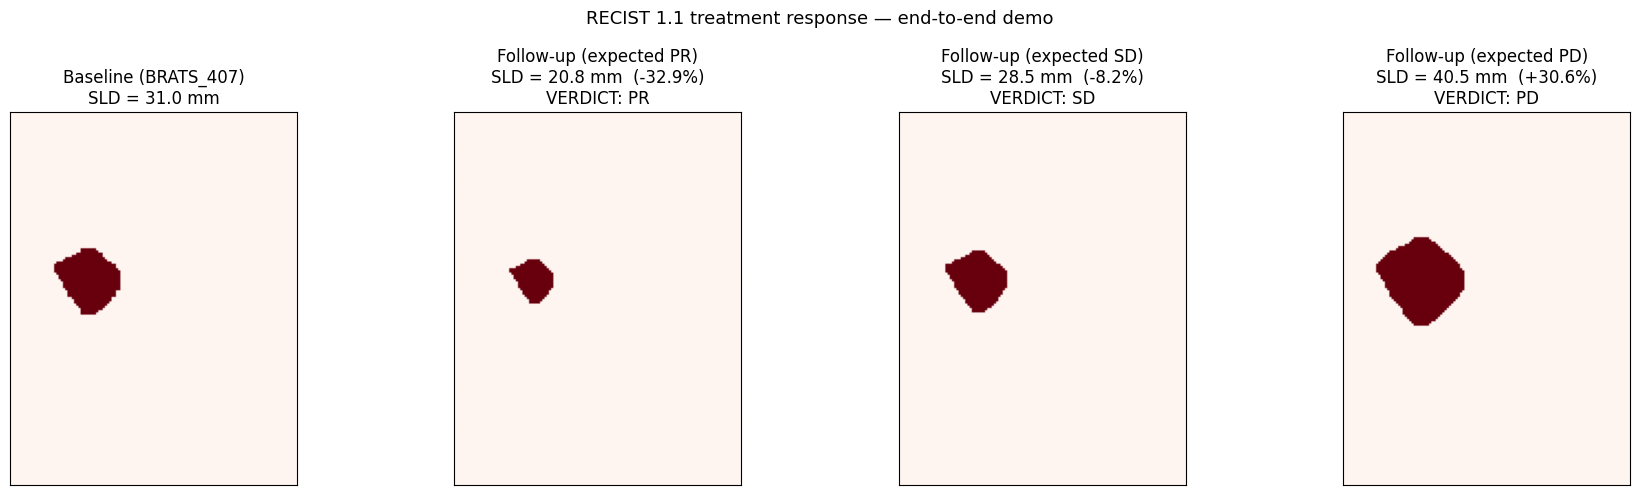

In [4]:
areas = et_baseline.sum(axis=(0, 1))
best_slice = int(np.argmax(areas))
print(f'Visualising axial slice {best_slice}')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(et_baseline[:, :, best_slice].T, cmap='Reds', origin='lower')
axes[0].set_title(f'Baseline ({BASELINE_SUBJECT})\nSLD = {scenarios["PR"]["result"].baseline_sum_ld:.1f} mm')
for i, key in enumerate(['PR', 'SD', 'PD']):
    fmask = scenarios[key]['followup_mask']
    res = scenarios[key]['result']
    axes[i + 1].imshow(fmask[:, :, best_slice].T, cmap='Reds', origin='lower')
    verdict = res.category.name
    axes[i + 1].set_title(
        f'Follow-up (expected {key})\n'
        f'SLD = {res.followup_sum_ld:.1f} mm  ({res.percent_change:+.1%})\n'
        f'VERDICT: {verdict}'
    )
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('RECIST 1.1 treatment response — end-to-end demo', fontsize=13)
fig.tight_layout()
out = ROOT / 'figures' / 'recist_demo.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
print(f'Saved {out}')

## 4. Summary of the clinical pipeline

```
raw MRI (4 modalities)
      ↓  OncoSeg inference (sliding window, sigmoid)
segmentation masks (TC / WT / ET)
      ↓  RECISTMeasurer.measure_lesions()
per-lesion longest diameter + volume
      ↓  ResponseClassifier.classify()
CR / PR / SD / PD verdict
```

Each scenario above returned the expected RECIST category, demonstrating the full loop. On real longitudinal data (two scans for the same patient), the same code path would produce the clinical verdict directly — no manual measurement required.